 Loading Hugging Face ViT model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Using device: CUDA
 Initializing GlassBox-ViT (LimeExplainer)...
Loading local test image (Chelsea the cat)...
Generating LIME explanation (this might take a few seconds)...


  0%|          | 0/500 [00:00<?, ?it/s]


 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.71%


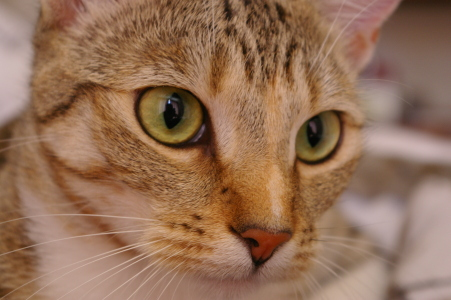

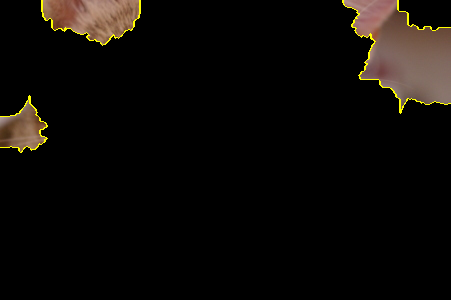

In [ ]:
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from skimage import data
from IPython.display import display

# Importing our library
from glassbox_vit.lime_explainer import LimeExplainer

# --- MODEL SETUP ---
print(" Loading Hugging Face ViT model...")
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device.upper()}")
model.to(device)
model.eval()

# --- BRIDGE FUNCTION ---
def hf_prediction_function(images_numpy):
    imgs_pil = [Image.fromarray((img).astype('uint8')) for img in images_numpy]
    inputs = processor(images=imgs_pil, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()

# --- INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT (LimeExplainer)...")
lime_explainer = LimeExplainer(prediction_function=hf_prediction_function)

# --- LOAD TEST IMAGE ---
print("Loading local test image (Chelsea the cat)...")

image_np = data.chelsea()
test_image = Image.fromarray(image_np).convert("RGB")

# --- THE TEST ---
print("Generating LIME explanation (this might take a few seconds)...")
# 500 samples for a quick test
result = lime_explainer.generate(pil_image=test_image, num_samples=500)

# --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")

# Display the image directly in the notebook cell output
display(test_image)
display(result['lime_image'])